# Task 2: Multi-Modal Cardiac Image Fusion

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def show(img, title, cmap='gray'):
    plt.figure(figsize=(5,5))
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis('off')
    plt.show()

## 1. Load Modalities

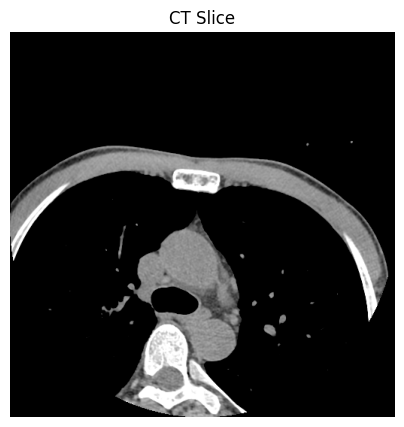

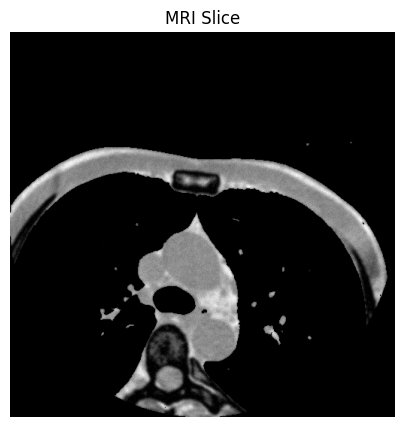

In [10]:
ct = cv2.imread('data/heart_ct.png', cv2.IMREAD_GRAYSCALE)
mri = cv2.imread('data/heart_mri.png', cv2.IMREAD_GRAYSCALE)
show(ct, 'CT Slice')
show(mri, 'MRI Slice')

## 2. Histogram Equalization (independent)

In [ ]:
ct_eq = cv2.equalizeHist(ct)
mri_eq = cv2.equalizeHist(mri)

show(ct_eq, 'CT Histogram Equalized')
show(mri_eq, 'MRI Histogram Equalized')

## 3. Color Mapping

In [ ]:
ct_color = cv2.applyColorMap(ct_eq, cv2.COLORMAP_BONE)
mri_color = cv2.applyColorMap(mri_eq, cv2.COLORMAP_JET)

show(cv2.cvtColor(ct_color, cv2.COLOR_BGR2RGB), 'CT Color Map', cmap=None)
show(cv2.cvtColor(mri_color, cv2.COLOR_BGR2RGB), 'MRI Color Map', cmap=None)

## 4. Multi-Modal Weighted Fusion

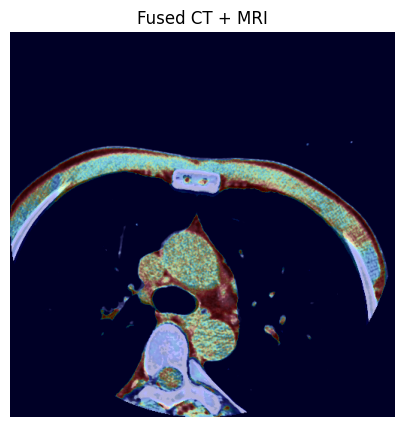

In [13]:
alpha = 0.7  # CT weight (structural edges)
beta = 0.3   # MRI weight (soft tissue)
fused = cv2.addWeighted(ct_color, alpha, mri_color, beta, 0)
show(cv2.cvtColor(fused, cv2.COLOR_BGR2RGB), 'Fused CT + MRI', cmap=None)

## 5. Logarithmic and Power-Law Transformations on fused output

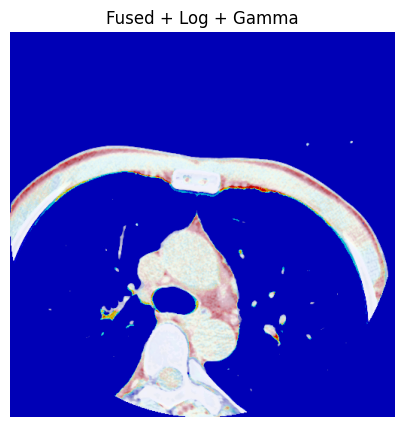

In [14]:
fused_f = fused.astype(np.float32) + 1
c = 255 / np.log(1 + np.max(fused_f))
fused_log = (c * np.log(fused_f)).astype(np.uint8)

gamma = 0.8
fused_norm = fused_log.astype(np.float32) / 255.0
fused_gamma = (np.power(fused_norm, gamma) * 255).astype(np.uint8)
show(cv2.cvtColor(fused_gamma, cv2.COLOR_BGR2RGB), 'Fused + Log + Gamma', cmap=None)

## 6. Comparative Analysis (side-by-side)

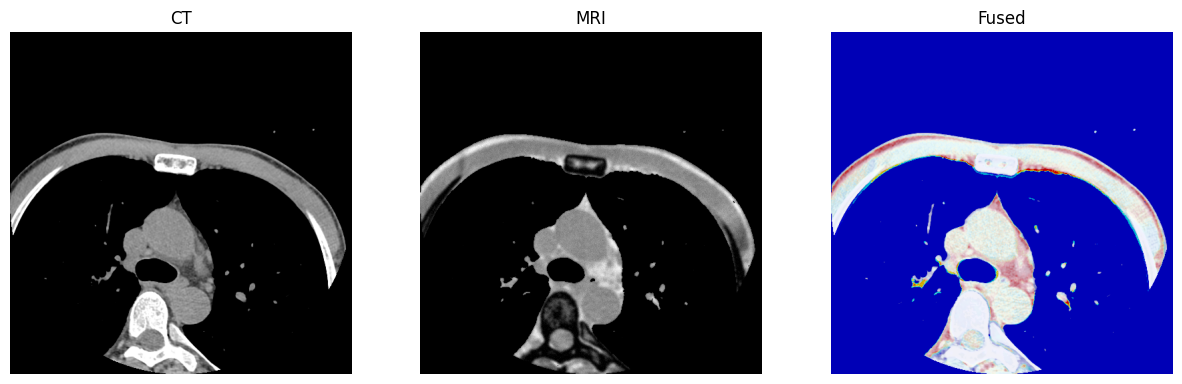

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))
axes[0].imshow(ct, cmap='gray'); axes[0].set_title('CT'); axes[0].axis('off')
axes[1].imshow(mri, cmap='gray'); axes[1].set_title('MRI'); axes[1].axis('off')
axes[2].imshow(cv2.cvtColor(fused_gamma, cv2.COLOR_BGR2RGB)); axes[2].set_title('Fused'); axes[2].axis('off')
plt.savefig('output/comparison.png', bbox_inches='tight')
plt.show()

In [16]:
import os

OUTPUT_DIR = 'output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Save every image shown in the notebook
cv2.imwrite(os.path.join(OUTPUT_DIR, 'ct_slice.png'), ct)
cv2.imwrite(os.path.join(OUTPUT_DIR, 'mri_slice.png'), mri)
cv2.imwrite(os.path.join(OUTPUT_DIR, 'ct_hist_equalized.png'), ct_eq)
cv2.imwrite(os.path.join(OUTPUT_DIR, 'mri_hist_equalized.png'), mri_eq)
cv2.imwrite(os.path.join(OUTPUT_DIR, 'ct_color_map.png'), ct_color)
cv2.imwrite(os.path.join(OUTPUT_DIR, 'mri_color_map.png'), mri_color)
cv2.imwrite(os.path.join(OUTPUT_DIR, 'fused_ct_mri.png'), fused)
cv2.imwrite(os.path.join(OUTPUT_DIR, 'fused_log_gamma.png'), fused_gamma)
cv2.imwrite(os.path.join(OUTPUT_DIR, 'comparison.png'), cv2.cvtColor(fused_gamma, cv2.COLOR_BGR2RGB))

print(f'Saved all displayed notebook images to {os.path.abspath(OUTPUT_DIR)}/')

Saved all displayed notebook images to c:\Users\arsha\OneDrive\Desktop\Arsh_Medical_Imaging_Portfolio\Task_2_Cardiac_Fusion\output/
